# Algorithms

In [318]:
import matplotlib.pyplot as plt
import numpy as np
import time
from dataclasses import dataclass
from abc import ABC, abstractmethod

np.random.seed(12345)
FINE_TUNE_SPEA = 100

## Preprocessing

In [303]:
@dataclass
class PMedianInstance:
    instance_id: int
    best_known: int
    num_customers: int
    num_medians: int
    capacity: int
    customer_ids: np.ndarray
    coords: np.ndarray
    demands: np.ndarray

    def __repr__(self):
        return (
            f"PMedianInstance(id={self.instance_id}, best_known={self.best_known}, "
            f"customers={self.num_customers}, medians={self.num_medians}, "
            f"capacity={self.capacity})"
        )


def parse_instances(raw: str) -> np.ndarray:
    lines = [l.strip() for l in raw.strip().splitlines() if l.strip()]
    parsed: list[PMedianInstance] = []
    i = 0
    while i < len(lines):
        # First line: instance_id  best_known_solution
        parts = lines[i].split()
        instance_id = int(parts[0])
        best_known = int(parts[1])
        i += 1

        # Second line: num_customers  num_medians  capacity
        parts = lines[i].split()
        num_customers = int(parts[0])
        num_medians = int(parts[1])
        capacity = int(parts[2])
        i += 1

        # Remaining lines for this instance: customer_id  x  y  demand
        cids, xs, ys, ds = [], [], [], []
        for _ in range(num_customers):
            parts = lines[i].split()
            cids.append(int(parts[0]))
            xs.append(int(parts[1]))
            ys.append(int(parts[2]))
            ds.append(int(parts[3]))
            i += 1

        parsed.append(PMedianInstance(
            instance_id=instance_id,
            best_known=best_known,
            num_customers=num_customers,
            num_medians=num_medians,
            capacity=capacity,
            customer_ids=np.array(cids),
            coords=np.column_stack([xs, ys]),
            demands=np.array(ds),
        ))

    # 0-indexed: arr[idx] is the instance with instance_id == idx+1
    arr = np.empty(len(parsed), dtype=object)
    for inst in parsed:
        arr[inst.instance_id - 1] = inst
    return arr


def load_instance(instance_id: int, filepath: str = "p_median_capacitated.txt") -> PMedianInstance:
    with open(filepath) as f:
        raw = f.read()
    return parse_instances(raw)[instance_id - 1]


def load_instance_from_string(raw: str, instance_id: int) -> PMedianInstance:
    return parse_instances(raw)[instance_id - 1]


def load_all_instances(filepath: str = "p_median_capacitated.txt") -> np.ndarray:
    with open(filepath) as f:
        raw = f.read()
    return parse_instances(raw)

In [304]:
# Sanity check - load instance 1 and verify against known values from the assignment
inst = load_instance(1)
print(inst)
assert inst.num_customers == 50
assert inst.num_medians == 5
assert inst.capacity == 120
assert inst.best_known == 713
assert inst.customer_ids[0] == 1
assert list(inst.coords[0]) == [2, 62]
assert inst.demands[0] == 3
print(f"Customers: {inst.num_customers}, first coords: {inst.coords[0]}, first demand: {inst.demands[0]}")
print(f"Total demand: {inst.demands.sum()}, total capacity: {inst.capacity * inst.num_medians}")

PMedianInstance(id=1, best_known=713, customers=50, medians=5, capacity=120)
Customers: 50, first coords: [ 2 62], first demand: 3
Total demand: 490, total capacity: 600


In [305]:
# Overview of all 18 benchmark instances
all_instances = load_all_instances()
for inst in all_instances:
    print(
        f"Instance {inst.instance_id:2d}: {inst.num_customers:3d} customers, "
        f"{inst.num_medians:2d} medians, capacity={inst.capacity}, "
        f"best_known={inst.best_known}, total_demand={inst.demands.sum()}"
    )

Instance  1:  50 customers,  5 medians, capacity=120, best_known=713, total_demand=490
Instance  2:  50 customers,  5 medians, capacity=120, best_known=740, total_demand=502
Instance  3:  50 customers,  5 medians, capacity=120, best_known=751, total_demand=512
Instance  4:  50 customers,  5 medians, capacity=120, best_known=651, total_demand=517
Instance  5:  50 customers,  5 medians, capacity=120, best_known=664, total_demand=541
Instance  6:  50 customers,  5 medians, capacity=120, best_known=778, total_demand=550
Instance  7:  50 customers,  5 medians, capacity=120, best_known=787, total_demand=551
Instance  8:  50 customers,  5 medians, capacity=120, best_known=820, total_demand=552
Instance  9:  50 customers,  5 medians, capacity=120, best_known=715, total_demand=559
Instance 10:  50 customers,  5 medians, capacity=120, best_known=829, total_demand=574
Instance 11: 100 customers, 10 medians, capacity=120, best_known=1006, total_demand=1017
Instance 12: 100 customers, 10 medians, c

### Stoppage criterions

In [ ]:
class StoppingCriterion(ABC):
    def reset(self):
        pass
    @abstractmethod
    def should_stop(self, gen: int, history: dict) -> bool: ...
    @abstractmethod
    def __repr__(self) -> str: ...


class MaxGenerations(StoppingCriterion):
    def __init__(self, n: int):
        assert n > 0, "n must be > 0"
        self.n = n
    def should_stop(self, gen, history):
        return gen + 1 >= self.n
    def __repr__(self):
        return f"MaxGenerations({self.n})"


class TimeLimit(StoppingCriterion):
    def __init__(self, seconds: float):
        assert seconds > 0, "seconds must be > 0"
        self.seconds = seconds
        self._start = None
    def reset(self):
        self._start = time.monotonic()
    def should_stop(self, gen, history):
        return (time.monotonic() - self._start) >= self.seconds
    def __repr__(self):
        return f"TimeLimit({self.seconds}s)"


class MinImprovement(StoppingCriterion):
    def __init__(self, window: int, min_pct: float):
        assert window > 0, "window must be > 0"
        assert 0 <= min_pct < 1, "min_pct must be in [0, 1)"
        self.window = window
        self.min_pct = np.clip(min_pct, 1e-15, 1. - 1e-15)
        self._buf: np.ndarray = np.empty(0)
    def reset(self):
        self._buf = np.empty(0)
    def should_stop(self, gen, history):
        current = history["best_service_dist"][-1]
        self._buf = np.append(self._buf, current)[-self.window:]
        if len(self._buf) < self.window:
            return False
        oldest = self._buf[0]
        if oldest == 0:
            return False
        improvement = (oldest - current) / oldest
        return improvement <= self.min_pct
    def __repr__(self):
        return f"MinImprovement(window={self.window}, min_pct={self.min_pct})"


class TargetObjective(StoppingCriterion):
    def __init__(self, target: float):
        assert target > 0, "target must be > 0"
        self.target = target
    def should_stop(self, gen, history):
        h = history["best_service_dist"]
        return bool(h) and h[-1] <= self.target
    def __repr__(self):
        return f"TargetObjective({self.target})"

## Non-dominated Sorting Genetic Algorithm (NSGA)

## Strength Pareto Evolutionary Algorithm (SPEA)

SPEA2 - Strength Pareto Evolutionary Algorithm 2

Implementation follows Algorithms 105-107 from "Essentials of Metaheuristics" (Sean Luke), adapted for the capacitated p-median problem.

Representation (n-Queens style, per lecture slide 17):
  An integer array of length num_customers where
  individual[i] = median ID (0 to p-1) that customer i is assigned to.
  Facility locations are derived as the customer nearest to each cluster's centroid.

Objectives (both treated as minimisation):
1. Service distance + capacity penalty (minimize, internal use only)
2. Negative facility dispersion (minimize == maximize dispersion)

#### Problem-specific helpers

In [ ]:
def compute_facility_locations(individual, coords, num_medians):
    facility_coords = np.empty((num_medians, 2), dtype=float)
    for m in range(num_medians):
        mask = individual == m
        if mask.any():
            centroid = coords[mask].mean(axis=0)
            dists = np.linalg.norm(coords[mask] - centroid, axis=1)
            closest_idx = np.where(mask)[0][np.argmin(dists)]
            facility_coords[m] = coords[closest_idx]
        else:
            # Empty cluster - place at a random customer location
            facility_coords[m] = coords[np.random.randint(len(coords))]
    return facility_coords


def compute_service_distance(individual, coords, facility_coords):
    return np.linalg.norm(coords - facility_coords[individual], axis=1).sum()


def compute_dispersion(facility_coords):
    p = len(facility_coords)
    total = 0.0
    for i in range(p):
        diff = facility_coords[i + 1:] - facility_coords[i]
        total += np.sqrt((diff ** 2).sum(axis=1)).sum()
    return total


def compute_capacity_penalty(individual, demands, capacity, num_medians, penalty_weight):
    penalty = 0.0
    for m in range(num_medians):
        excess = demands[individual == m].sum() - capacity
        if excess > 0:
            penalty += excess
    return penalty_weight * penalty


def is_feasible(individual, demands, capacity, num_medians):
    for m in range(num_medians):
        if demands[individual == m].sum() > capacity:
            return False
    return True


def repair_capacity(individual, coords, demands, capacity, num_medians):
    child = individual.copy()
    loads = np.array([demands[child == m].sum() for m in range(num_medians)])

    for m in range(num_medians):
        if loads[m] <= capacity:
            continue
        # Compute all facility locations once per overloaded-facility pass
        fac_coords = compute_facility_locations(child, coords, num_medians)
        assigned = np.where(child == m)[0]
        dists_to_fac = np.linalg.norm(coords[assigned] - fac_coords[m], axis=1)
        order = np.argsort(-dists_to_fac)  # farthest first

        for idx in order:
            if loads[m] <= capacity:
                break
            cust = assigned[idx]
            cust_demand = demands[cust]

            # Find nearest under-capacity facility for this customer
            best_target = -1
            best_dist = np.inf
            for t in range(num_medians):
                if t == m:
                    continue
                if loads[t] + cust_demand <= capacity:
                    d = np.linalg.norm(coords[cust] - fac_coords[t])
                    if d < best_dist:
                        best_dist = d
                        best_target = t

            if best_target >= 0:
                child[cust] = best_target
                loads[m] -= cust_demand
                loads[best_target] += cust_demand

    return child


def evaluate_population(pop, instance, penalty_weight):
    n = len(pop)
    objectives = np.empty((n, 2))
    raw_dists = np.empty(n)
    for i in range(n):
        ind = pop[i]
        fac = compute_facility_locations(ind, instance.coords,
                                         instance.num_medians)
        dist = compute_service_distance(ind, instance.coords, fac)
        pen = compute_capacity_penalty(ind, instance.demands,
                                       instance.capacity,
                                       instance.num_medians,
                                       penalty_weight)
        disp = compute_dispersion(fac)
        raw_dists[i] = dist
        objectives[i, 0] = dist + pen     # minimise (internal, penalized)
        objectives[i, 1] = -disp          # minimise (maximise dispersion)
    return objectives, raw_dists

#### Pareto utilities
Algorithms 98, 100

In [308]:
def dominates(a, b):
    return bool(np.all(a <= b) and np.any(a < b))

def compute_pareto_front(objectives):
    n = len(objectives)
    is_dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        if is_dominated[i]:
            continue
        for j in range(n):
            if i == j or is_dominated[j]:
                continue
            if dominates(objectives[j], objectives[i]):
                is_dominated[i] = True
                break
    return ~is_dominated

#### SPEA2 fitness assignment
§7.3 + Algorithm 105

In [309]:
def compute_strength(objectives):
    n = len(objectives)
    strength = np.zeros(n, dtype=int)
    for i in range(n):
        for j in range(n):
            if i != j and dominates(objectives[i], objectives[j]):
                strength[i] += 1
    return strength


def compute_wimpiness(objectives, strength):
    n = len(objectives)
    wimpiness = np.zeros(n, dtype=float)
    for i in range(n):
        for j in range(n):
            if i != j and dominates(objectives[j], objectives[i]):
                wimpiness[i] += strength[j]
    return wimpiness


def compute_kth_nearest_distance(objectives, k):
    n = len(objectives)
    obj_min = objectives.min(axis=0)
    obj_max = objectives.max(axis=0)
    obj_range = obj_max - obj_min
    obj_range[obj_range == 0] = 1.0
    normed = (objectives - obj_min) / obj_range

    # Pairwise Euclidean distance matrix
    diff = normed[:, np.newaxis, :] - normed[np.newaxis, :, :]
    dist_matrix = np.sqrt((diff ** 2).sum(axis=2))

    kth_dist = np.empty(n)
    for i in range(n):
        sorted_d = np.sort(dist_matrix[i])
        # sorted_d[0] == 0 (self), so k-th nearest is at index k
        kth_dist[i] = sorted_d[min(k, n - 1)]
    return kth_dist


def compute_spea2_fitness(objectives):
    n = len(objectives)
    k = max(1, int(np.ceil(np.sqrt(n))))
    strength = compute_strength(objectives)
    wimpiness = compute_wimpiness(objectives, strength)
    kth_dist = compute_kth_nearest_distance(objectives, k)
    unfitness = wimpiness + 1.0 / (2.0 + kth_dist)
    return 1.0 / (1.0 + unfitness)

#### SPEA2 archive construction
Algorithm 106

In [ ]:
def construct_spea2_archive(pop, objectives, raw_dists, fitness, archive_size):
    # Step 1 - start with non-dominated front
    front_mask = compute_pareto_front(objectives)
    archive_idx = list(np.where(front_mask)[0])
    rest_idx = list(np.where(~front_mask)[0])

    # Step 2 - if too small, fill with fittest remaining
    if len(archive_idx) < archive_size and rest_idx:
        rest_fit = fitness[rest_idx]
        order = np.argsort(-rest_fit)
        needed = archive_size - len(archive_idx)
        archive_idx.extend(rest_idx[i] for i in order[:needed])

    # Step 3 - if too large, iteratively remove closest individual
    while len(archive_idx) > archive_size:
        arch_objs = objectives[archive_idx]
        obj_min = arch_objs.min(axis=0)
        obj_max = arch_objs.max(axis=0)
        obj_range = obj_max - obj_min
        obj_range[obj_range == 0] = 1.0
        normed = (arch_objs - obj_min) / obj_range

        m = len(archive_idx)
        diff = normed[:, np.newaxis, :] - normed[np.newaxis, :, :]
        dm = np.sqrt((diff ** 2).sum(axis=2))
        sorted_dm = np.sort(dm, axis=1)          # (m, m)

        # Find individual with smallest kth-closest (k=1, break ties k=2…)
        to_remove = 0
        for kk in range(1, m):
            col = sorted_dm[:, kk]
            min_val = col.min()
            candidates = np.where(np.isclose(col, min_val))[0]
            if len(candidates) == 1:
                to_remove = candidates[0]
                break
        else:
            to_remove = candidates[0]

        archive_idx.pop(to_remove)

    idx = np.array(archive_idx)
    return pop[idx], objectives[idx], raw_dists[idx]

#### Genetic operators

In [311]:
def initialize_population(pop_size, num_customers, num_medians, rng):
    pop = rng.integers(0, num_medians, size=(pop_size, num_customers))
    for i in range(pop_size):
        used = set(pop[i])
        for m in range(num_medians):
            if m not in used:
                pop[i, rng.integers(num_customers)] = m
    return pop


def tournament_selection(fitness, rng, tournament_size=2):
    candidates = rng.integers(0, len(fitness), size=tournament_size)
    return candidates[np.argmax(fitness[candidates])]


def uniform_crossover(p1, p2, rng, rate=0.8):
    if rng.random() > rate:
        return p1.copy(), p2.copy()
    mask = rng.random(len(p1)) < 0.5
    c1 = np.where(mask, p1, p2)
    c2 = np.where(mask, p2, p1)
    return c1, c2


def random_resetting_mutation(individual, num_medians, rng, rate):
    child = individual.copy()
    mask = rng.random(len(child)) < rate
    child[mask] = rng.integers(0, num_medians, size=mask.sum())
    return child


def breed(archive, archive_fitness, pop_size, num_medians, rng, crossover_rate, mutation_rate, instance=None):
    n_cust = archive.shape[1]
    children = np.empty((pop_size, n_cust), dtype=int)
    idx = 0
    while idx < pop_size:
        i1 = tournament_selection(archive_fitness, rng)
        i2 = tournament_selection(archive_fitness, rng)
        c1, c2 = uniform_crossover(archive[i1], archive[i2], rng, crossover_rate)
        c1 = random_resetting_mutation(c1, num_medians, rng, mutation_rate)
        c2 = random_resetting_mutation(c2, num_medians, rng, mutation_rate)
        # Repair capacity violations
        if instance is not None:
            c1 = repair_capacity(c1, instance.coords, instance.demands, instance.capacity, num_medians)
            c2 = repair_capacity(c2, instance.coords, instance.demands, instance.capacity, num_medians)
        children[idx] = c1
        idx += 1
        if idx < pop_size:
            children[idx] = c2
            idx += 1
    return children

#### SPEA2 main loop
Algorithm 107

In [ ]:
inst = load_instance(15)

if inst.num_customers <= 50:
    # instance 1 results
    # [ 11/100] pop=285, arch=49, penalty=1.27, cx=0.111, mut=0.083, seed=102, mult=0.301 ... dist=728.4  *** new best (732.2 -> 728.4) ***
    # [  7/500] pop=257, arch=41, penalty=1.84, cx=0.092, mut=0.058, seed=62, mult=0.329 ... dist=728.4  *** new best (732.2 -> 728.4) ***
    best_pop_size = 193
    best_archive_size = 51
    best_penalty = 1.62
    best_crossover_rate = 0.089
    best_mutation_rate = 0.076
    best_seed = 62
else:
    # Instance 15 results
    # [ 19/100] pop=288, arch=35, penalty=1.84, cx=0.059, mut=0.042, seed=90, mult=0.275 ... dist=1142.1 time=66.5633  *** new best (1153.0 -> 1142.1) ***
    best_pop_size = 288
    best_archive_size = 35
    best_penalty = 1.84
    best_crossover_rate = 0.059
    best_mutation_rate = 0.042
    best_seed = 90

def spea2(instance, pop_size=best_pop_size, archive_size=best_archive_size,
          stopping_criteria=None,
          penalty_weight=best_penalty, crossover_rate=best_crossover_rate, mutation_rate=best_mutation_rate,
          seed=best_seed, verbose=True):
    if stopping_criteria is None:
        stopping_criteria = [TimeLimit(60 * 5), MinImprovement(50, min_pct=0.02)]

    rng = np.random.default_rng(seed)
    n_cust = instance.num_customers
    n_med = instance.num_medians
    if mutation_rate is None:
        mutation_rate = 1.0 / n_cust

    # Initialise stopping criteria
    for criterion in stopping_criteria:
        criterion.reset()

    # Line 3 - initialise population
    P = initialize_population(pop_size, n_cust, n_med, rng)

    # Line 4 - empty archive
    A = np.empty((0, n_cust), dtype=int)
    A_obj = np.empty((0, 2))
    A_raw = np.empty(0)

    history = {
        "best_service_dist": [],   # true service distance, no penalty
        "best_dispersion": [],
        "front_sizes": [],
    }

    gen = 0
    while True:
        # Line 6 - evaluate new population
        P_obj, P_raw = evaluate_population(P, instance, penalty_weight)

        # Line 7 - P ← P ∪ A
        if len(A) > 0:
            combined = np.vstack([P, A])
            combined_obj = np.vstack([P_obj, A_obj])
            combined_raw = np.concatenate([P_raw, A_raw])
        else:
            combined = P
            combined_obj = P_obj
            combined_raw = P_raw

        # Compute SPEA2 fitness on combined pool
        combined_fit = compute_spea2_fitness(combined_obj)

        # Line 8 - best Pareto front (for tracking)
        front_mask = compute_pareto_front(combined_obj)

        # Line 9 - construct archive
        A, A_obj, A_raw = construct_spea2_archive(
            combined, combined_obj, combined_raw, combined_fit, archive_size
        )

        # Record history - use true service distance (no penalty)
        front_raw = combined_raw[front_mask]
        front_obj = combined_obj[front_mask]
        history["best_service_dist"].append(front_raw.min())
        history["best_dispersion"].append((-front_obj[:, 1]).max())
        history["front_sizes"].append(front_mask.sum())

        if verbose and ((gen + 1) % 50 == 0 or gen == 0):
            print(
                f"Gen {gen+1:4d}  |  front size {front_mask.sum():3d}  |  "
                f"best dist {front_raw.min():.1f}  |  "
                f"best disp {(-front_obj[:, 1]).max():.1f}"
            )

        # Check stopping criteria
        triggered = [c for c in stopping_criteria if c.should_stop(gen, history)]
        if triggered:
            if verbose:
                print(f"Stopped at gen {gen + 1} - triggered: {triggered}")
            break

        # Line 10 - breed new population from archive (with repair)
        A_fit = compute_spea2_fitness(A_obj) if len(A) > 1 else np.ones(len(A))
        P = breed(A, A_fit, pop_size, n_med, rng, crossover_rate,
                  mutation_rate, instance=instance)
        gen += 1

    # Final front from archive - filter to feasible solutions only
    final_mask = compute_pareto_front(A_obj)
    front_pop = A[final_mask]
    front_obj = A_obj[final_mask]
    front_raw = A_raw[final_mask]

    feasible_mask = np.array([
        is_feasible(ind, instance.demands, instance.capacity, n_med)
        for ind in front_pop
    ])

    if feasible_mask.any():
        front_pop = front_pop[feasible_mask]
        front_obj = front_obj[feasible_mask]
        front_raw = front_raw[feasible_mask]
    else:
        if verbose:
            print("WARNING: no feasible solution found on the Pareto front, returning all.")

    return {
        "archive": A,
        "archive_objectives": A_obj,
        "archive_raw_dists": A_raw,
        "front": front_pop,
        "front_objectives": front_obj,
        "front_raw_dists": front_raw,
        "history": history,
        "generations_run": gen + 1,
    }


print("SPEA2 implementation loaded.")

SPEA2 implementation loaded.


#### Fine-tuning

[  1/100] pop=240, arch=63, penalty=1.94, cx=0.100, mut=0.053, seed=69, mult=0.333 ... dist=1224.2 time=64.5414  *** new best (2182.0 -> 1224.2) ***


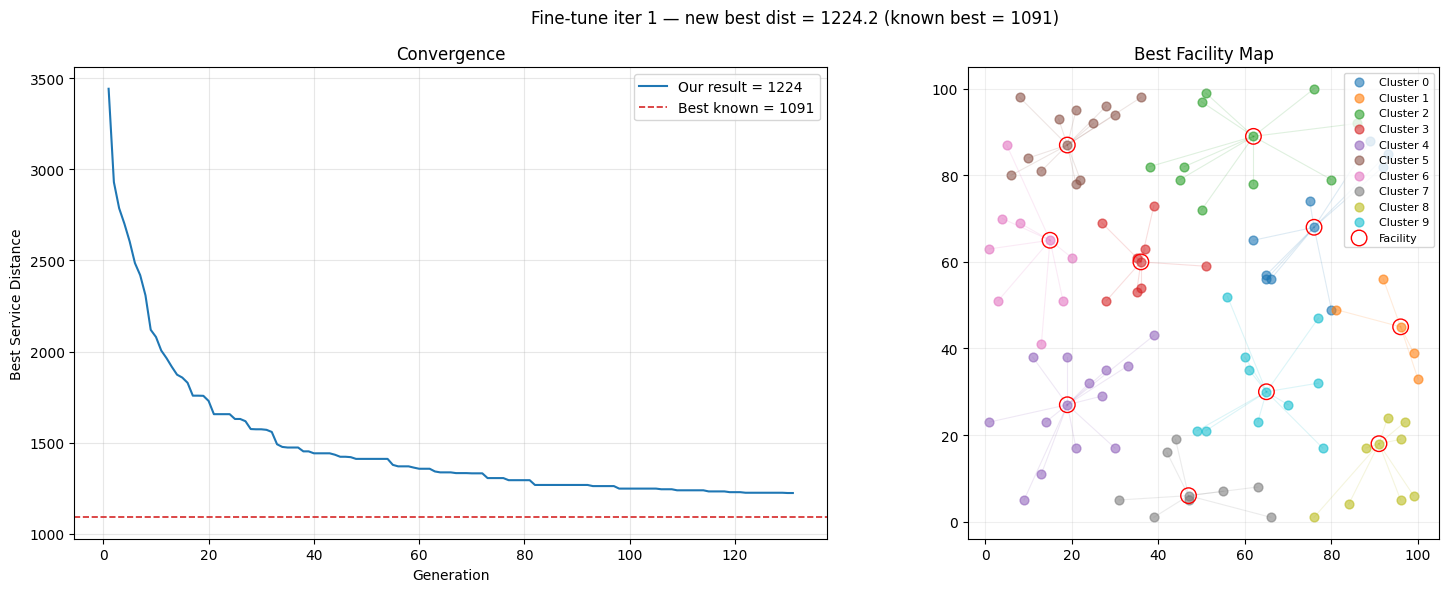

[  2/100] pop=200, arch=67, penalty=1.79, cx=0.109, mut=0.046, seed=47, mult=0.330 ... dist=1227.8 time=55.2279
[  3/100] pop=191, arch=66, penalty=2.05, cx=0.106, mut=0.069, seed=65, mult=0.327 ... dist=1381.6 time=41.8640
[  4/100] pop=190, arch=54, penalty=1.93, cx=0.087, mut=0.056, seed=85, mult=0.323 ... dist=1211.4 time=58.5617  *** new best (1224.2 -> 1211.4) ***


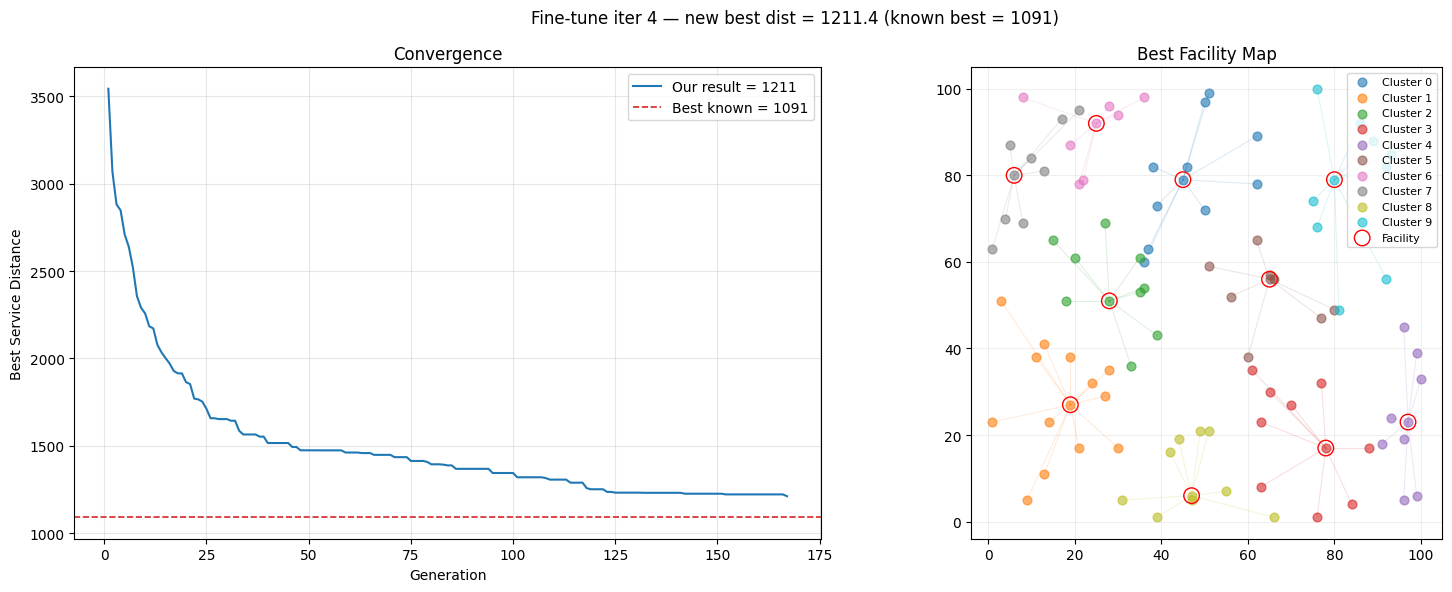

[  5/100] pop=232, arch=70, penalty=2.27, cx=0.065, mut=0.054, seed=75, mult=0.320 ... dist=1277.0 time=55.6431
[  6/100] pop=162, arch=68, penalty=2.45, cx=0.093, mut=0.059, seed=74, mult=0.317 ... dist=1289.7 time=40.6653
[  7/100] pop=175, arch=65, penalty=2.47, cx=0.097, mut=0.055, seed=110, mult=0.314 ... dist=1280.0 time=33.5194
[  8/100] pop=228, arch=46, penalty=2.07, cx=0.067, mut=0.049, seed=78, mult=0.310 ... dist=1239.4 time=46.4502
[  9/100] pop=228, arch=39, penalty=1.92, cx=0.072, mut=0.045, seed=82, mult=0.307 ... dist=1218.7 time=51.1618
[ 10/100] pop=226, arch=48, penalty=1.49, cx=0.086, mut=0.047, seed=83, mult=0.304 ... dist=1246.8 time=41.6561
[ 11/100] pop=220, arch=49, penalty=1.51, cx=0.080, mut=0.043, seed=93, mult=0.301 ... dist=1215.1 time=46.9712
[ 12/100] pop=238, arch=64, penalty=2.08, cx=0.061, mut=0.070, seed=79, mult=0.297 ... dist=1244.6 time=73.5367
[ 13/100] pop=197, arch=60, penalty=1.63, cx=0.074, mut=0.068, seed=75, mult=0.294 ... dist=1299.1 time

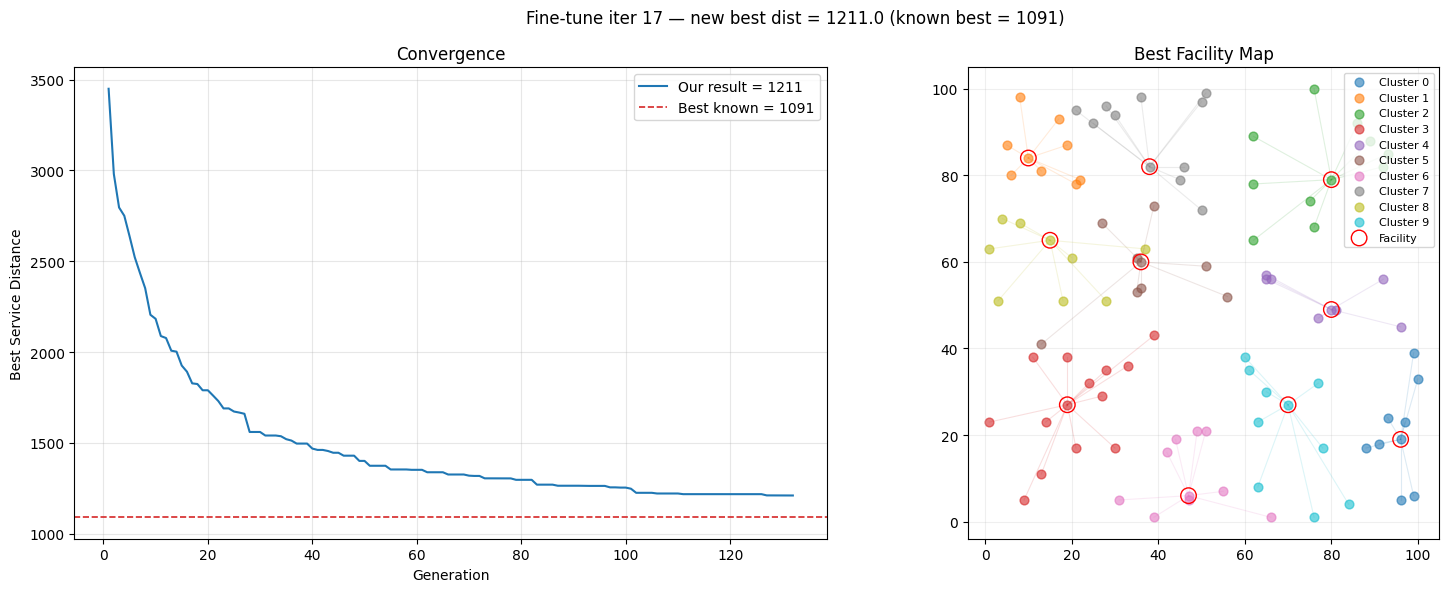

[ 18/100] pop=239, arch=46, penalty=2.29, cx=0.077, mut=0.035, seed=84, mult=0.278 ... dist=1153.0 time=47.9376  *** new best (1211.0 -> 1153.0) ***


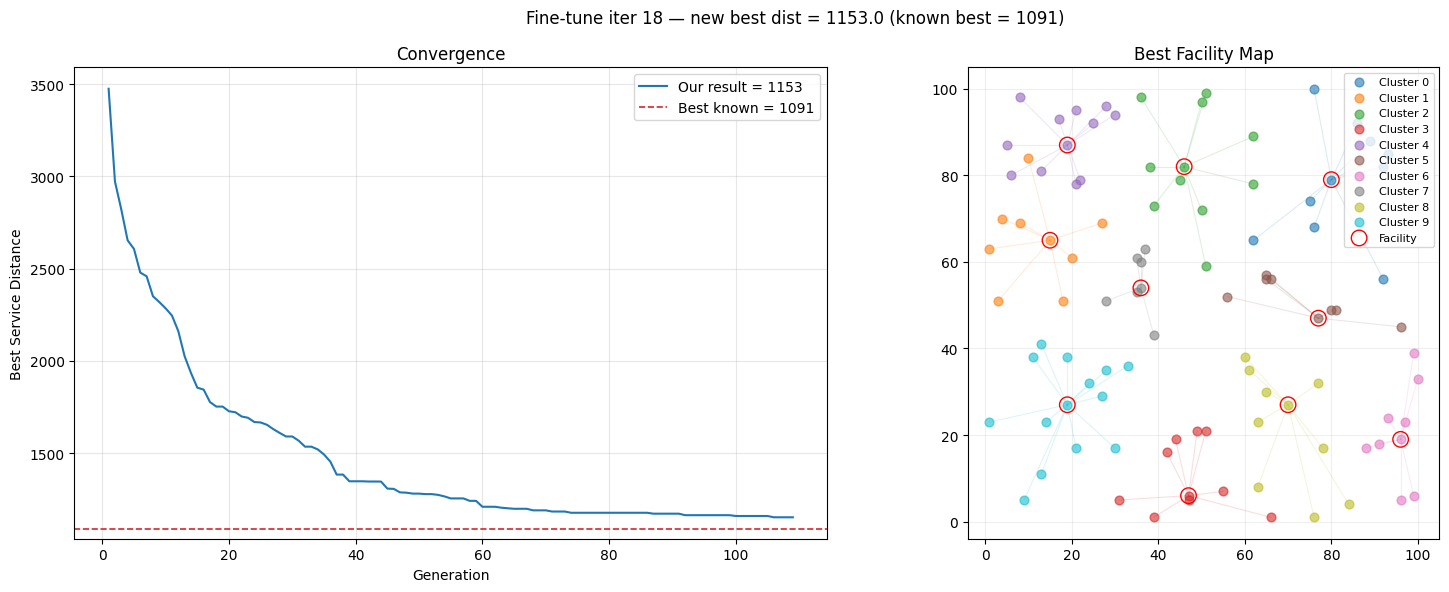

[ 19/100] pop=288, arch=35, penalty=1.84, cx=0.059, mut=0.042, seed=90, mult=0.275 ... dist=1142.1 time=66.5633  *** new best (1153.0 -> 1142.1) ***


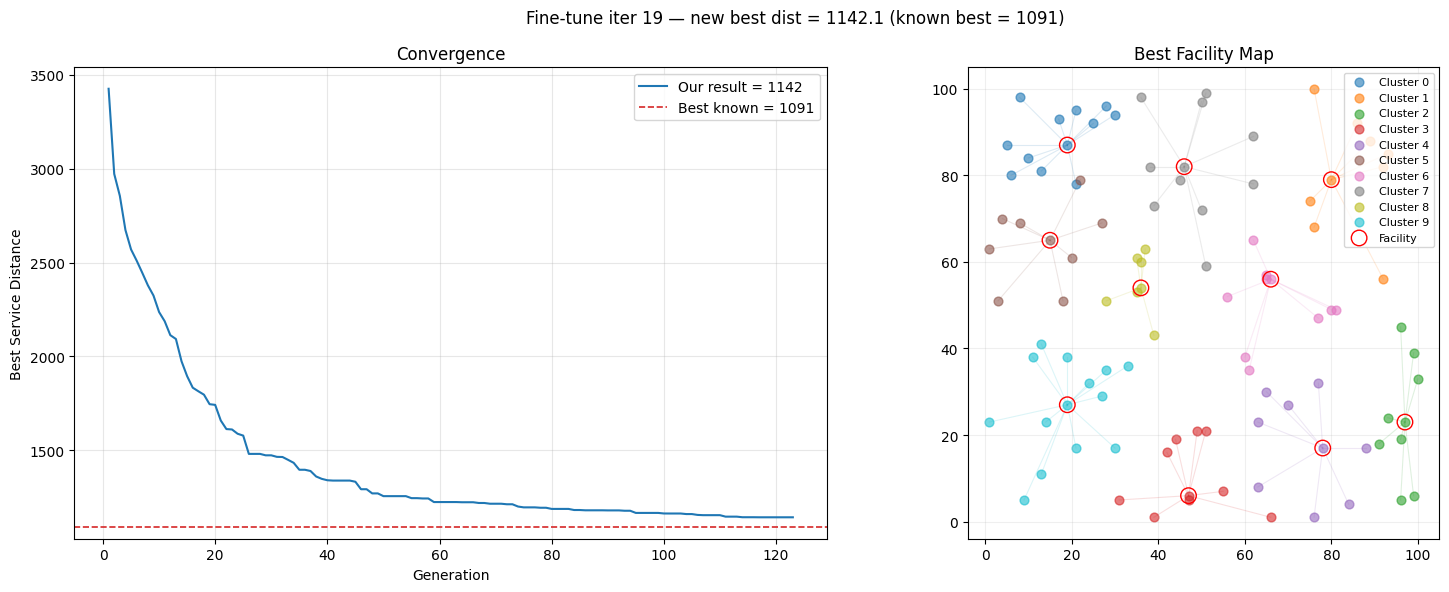

[ 20/100] pop=258, arch=29, penalty=1.80, cx=0.067, mut=0.051, seed=84, mult=0.272 ... dist=1186.3 time=64.3669
[ 21/100] pop=283, arch=39, penalty=1.60, cx=0.073, mut=0.036, seed=114, mult=0.268 ... dist=1254.6 time=55.1704
[ 22/100] pop=302, arch=38, penalty=1.41, cx=0.060, mut=0.032, seed=75, mult=0.265 ... dist=1220.4 time=62.8779
[ 23/100] pop=293, arch=36, penalty=1.45, cx=0.065, mut=0.044, seed=70, mult=0.262 ... dist=1173.2 time=79.4008
[ 24/100] pop=338, arch=29, penalty=1.76, cx=0.068, mut=0.039, seed=100, mult=0.259 ... dist=1197.9 time=79.3070
[ 25/100] pop=349, arch=30, penalty=2.05, cx=0.052, mut=0.036, seed=109, mult=0.255 ... 

KeyboardInterrupt: 

In [313]:
if FINE_TUNE_SPEA > 0:
    multiplier = 0.333
    min_multiplier = 0.01
    max_i = FINE_TUNE_SPEA
    multiplier_step = (multiplier - min_multiplier) / max_i

    best_result = float(inst.best_known * 2.)
    best_time = 99999
    best_run_result = None

    for i in range(max_i):
        pop_low = max(2, int(best_pop_size * (1.0 - multiplier)))
        pop_high = max(pop_low + 1, int(best_pop_size * (1.0 + multiplier)) + 1)
        pop_size = np.random.randint(pop_low, pop_high)

        arch_low = max(1, int(best_archive_size * (1.0 - multiplier)))
        arch_high = min(pop_size, int(best_archive_size * (1.0 + multiplier)))
        archive_size = np.random.randint(arch_low, max(arch_low + 1, arch_high + 1))

        penalty = np.random.uniform(
            max(0.0, best_penalty * (1.0 - multiplier)),
            max(0.0, best_penalty * (1.0 + multiplier))
        )
        crossover_rate = np.random.uniform(
            max(0.0, best_crossover_rate * (1.0 - multiplier)),
            min(1.0, best_crossover_rate * (1.0 + multiplier))
        )
        mutation_rate = np.random.uniform(
            max(0.0, best_mutation_rate * (1.0 - multiplier)),
            min(1.0, best_mutation_rate * (1.0 + multiplier))
        )

        seed_low = max(0, int(best_seed * (1.0 - multiplier)))
        seed_high = min(np.iinfo(np.uint32).max, int(best_seed * (1.0 + multiplier)))
        seed = np.random.randint(seed_low, max(seed_low + 1, seed_high + 1))

        print(
            f"[{i+1:3d}/{max_i}] pop={pop_size}, arch={archive_size}, "
            f"penalty={penalty:.2f}, cx={crossover_rate:.3f}, "
            f"mut={mutation_rate:.3f}, seed={seed}, mult={multiplier:.3f}",
            end=" ... "
        )

        start_time = time.monotonic()
        result = spea2(
            inst,
            pop_size=pop_size,
            archive_size=archive_size,
            penalty_weight=penalty,
            crossover_rate=crossover_rate,
            mutation_rate=mutation_rate,
            seed=seed,
            stopping_criteria=[
                TimeLimit(120),
                MinImprovement(50, min_pct=0.03),
            ],
            verbose=False,
        )
        local_time = time.monotonic() - start_time

        local_best = result["front_raw_dists"].min()
        print(f"dist={local_best:.1f} time={local_time:.4f}", end="")
        is_best = local_best < best_result

        if is_best or (local_best == best_result and local_time < best_time):
            if is_best:
                print(f"  *** new best ({best_result:.1f} -> {local_best:.1f}) ***")
            else:
                print(f"  *** time improvement ({best_time:.4f} -> {local_time:.4f}) ***")
            best_result = local_best
            best_time = local_time
            best_pop_size = pop_size
            best_archive_size = archive_size
            best_penalty = penalty
            best_crossover_rate = crossover_rate
            best_mutation_rate = mutation_rate
            best_seed = seed
            best_run_result = result

            # Plot the new best solution
            best_idx = np.argmin(best_run_result["front_raw_dists"])
            best_ind = best_run_result["front"][best_idx]
            best_fac = compute_facility_locations(best_ind, inst.coords, inst.num_medians)

            fig, axes = plt.subplots(1, 2, figsize=(16, 6))
            fig.suptitle(
                f"Fine-tune iter {i+1} - new best dist = {local_best:.1f} "
                f"(known best = {inst.best_known})",
                fontsize=12
            )

            # Left: convergence of this run
            gens = range(1, len(best_run_result["history"]["best_service_dist"]) + 1)
            axes[0].plot(gens, best_run_result["history"]["best_service_dist"], color="tab:blue", label=f"Our result = {local_best:.0f}")
            axes[0].axhline(y=inst.best_known, color="tab:red", linestyle="--",
                            linewidth=1.2, label=f"Best known = {inst.best_known}")
            axes[0].set_xlabel("Generation")
            axes[0].set_ylabel("Best Service Distance")
            axes[0].set_title("Convergence")
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            # Right: facility map
            cmap = plt.colormaps.get_cmap("tab10").resampled(inst.num_medians)
            for m in range(inst.num_medians):
                mask = best_ind == m
                axes[1].scatter(
                    inst.coords[mask, 0], inst.coords[mask, 1],
                    color=cmap(m), alpha=0.6, s=40, label=f"Cluster {m}"
                )
                for ci in np.where(mask)[0]:
                    axes[1].plot(
                        [inst.coords[ci, 0], best_fac[m, 0]],
                        [inst.coords[ci, 1], best_fac[m, 1]],
                        color=cmap(m), alpha=0.15, linewidth=0.8
                    )
            axes[1].scatter(
                best_fac[:, 0], best_fac[:, 1],
                marker="o", s=125, color="red", facecolors="none", zorder=10, label="Facility"
            )
            axes[1].set_title("Best Facility Map")
            axes[1].legend(loc="upper right", fontsize=8)
            axes[1].grid(True, alpha=0.2)
            axes[1].set_aspect("equal")

            plt.tight_layout()
            plt.show()
        else:
            print()

        multiplier = max(min_multiplier, multiplier - multiplier_step)

    print("\nBest tuning result:")
    print(f"  best_result      = {best_result:.4f}")
    print(f"  pop_size         = {best_pop_size}")
    print(f"  archive_size     = {best_archive_size}")
    print(f"  penalty          = {best_penalty:.4f}")
    print(f"  crossover_rate   = {best_crossover_rate:.4f}")
    print(f"  mutation_rate    = {best_mutation_rate:.4f}")
    print(f"  seed             = {best_seed}")

In [320]:
result = spea2(
    inst,
    pop_size=best_pop_size,
    archive_size=best_archive_size,
    stopping_criteria=[
        TimeLimit(60 * 5),
        MinImprovement(50, min_pct=0.),
        TargetObjective(inst.best_known),
    ],
    penalty_weight=best_penalty,
    seed=best_seed,
)

our_distance = result['front_raw_dists'].min()
print(f"\nGenerations run:         {result['generations_run']}")
print(f"Final Pareto front size: {len(result['front'])}")
print(f"Best service distance:   {our_distance:.1f}")
print(f"Best dispersion:         {(-result['front_objectives'][:, 1]).max():.1f}")
print(f"Known best (single-obj): {inst.best_known}")

Gen    1  |  front size   5  |  best dist 3426.5  |  best disp 1887.1
Gen   50  |  front size  15  |  best dist 1342.3  |  best disp 2760.8
Gen  100  |  front size  30  |  best dist 1263.7  |  best disp 2859.3
Gen  150  |  front size  26  |  best dist 1224.0  |  best disp 2871.2
Gen  200  |  front size  38  |  best dist 1181.0  |  best disp 2886.5
Gen  250  |  front size  25  |  best dist 1149.4  |  best disp 2921.8
Gen  300  |  front size  26  |  best dist 1145.2  |  best disp 2922.3
Gen  350  |  front size  45  |  best dist 1144.9  |  best disp 2922.3
Gen  400  |  front size  45  |  best dist 1143.5  |  best disp 2929.4
Stopped at gen 400 — triggered: [MinImprovement(window=50, min_pct=1e-15)]

Generations run:         400
Final Pareto front size: 35
Best service distance:   1143.5
Best dispersion:         2929.4
Known best (single-obj): 1091


### Visualisations

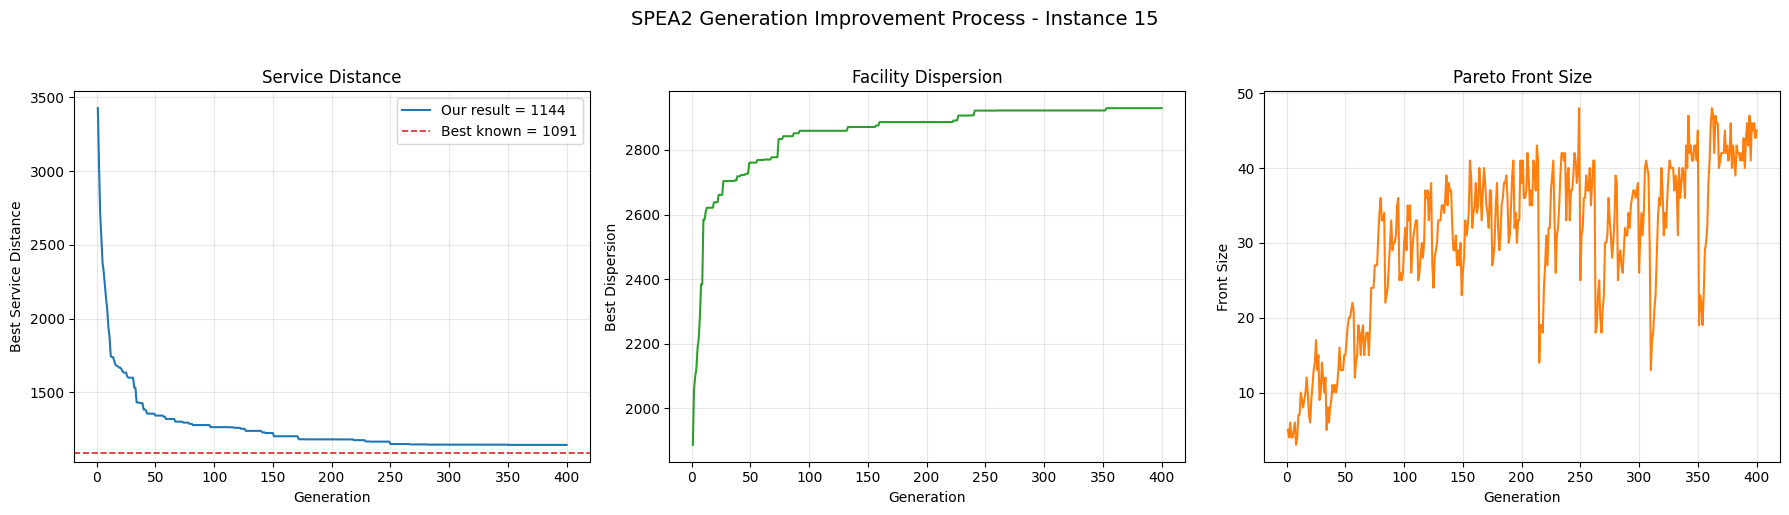

In [321]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

gens = range(1, len(result["history"]["best_service_dist"]) + 1)

# Service distance convergence
axes[0].plot(gens, result["history"]["best_service_dist"], color="tab:blue", label=f"Our result = {our_distance:.0f}")
axes[0].axhline(y=inst.best_known, color="tab:red", linestyle="--", linewidth=1.2,
                label=f"Best known = {inst.best_known}")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Best Service Distance")
axes[0].set_title("Service Distance")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dispersion convergence
axes[1].plot(gens, result["history"]["best_dispersion"], color="tab:green")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Best Dispersion")
axes[1].set_title("Facility Dispersion")
axes[1].grid(True, alpha=0.3)

# Pareto front size
axes[2].plot(gens, result["history"]["front_sizes"], color="tab:orange")
axes[2].set_xlabel("Generation")
axes[2].set_ylabel("Front Size")
axes[2].set_title("Pareto Front Size")
axes[2].grid(True, alpha=0.3)

fig.suptitle(f"SPEA2 Generation Improvement Process - Instance {inst.instance_id}", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

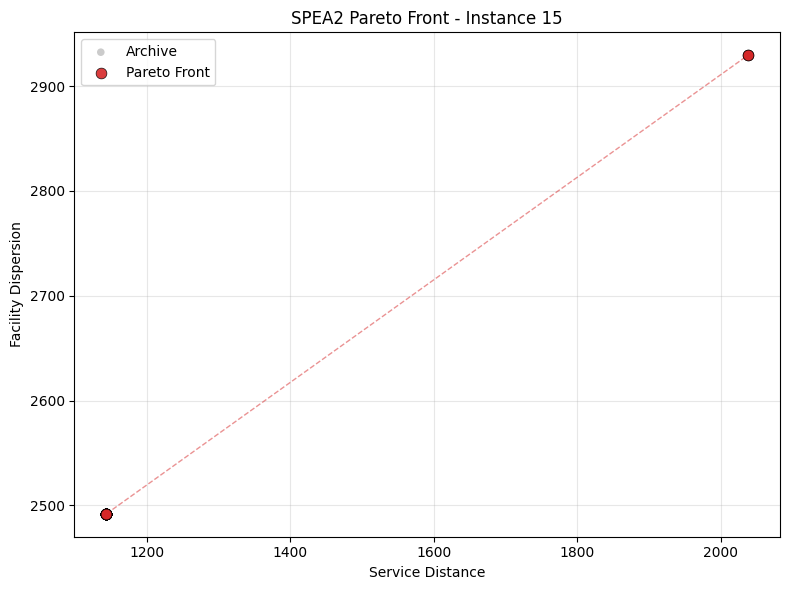

In [322]:
# Pareto front scatter plot - final archive
fig, ax = plt.subplots(figsize=(8, 6))

# All archive members
ax.scatter(
    result["archive_raw_dists"],
    -result["archive_objectives"][:, 1],
    alpha=0.4, label="Archive", color="tab:gray", edgecolors="none", s=30
)

# Non-dominated front
ax.scatter(
    result["front_raw_dists"],
    -result["front_objectives"][:, 1],
    alpha=0.9, label="Pareto Front", color="tab:red", edgecolors="black",
    linewidths=0.5, s=60, zorder=5
)

# Sort front by service distance and connect with line
sorted_idx = np.argsort(result["front_raw_dists"])
ax.plot(
    result["front_raw_dists"][sorted_idx],
    -result["front_objectives"][sorted_idx, 1],
    color="tab:red", alpha=0.5, linestyle="--", linewidth=1
)

ax.set_xlabel("Service Distance")
ax.set_ylabel("Facility Dispersion")
ax.set_title(f"SPEA2 Pareto Front - Instance {inst.instance_id}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

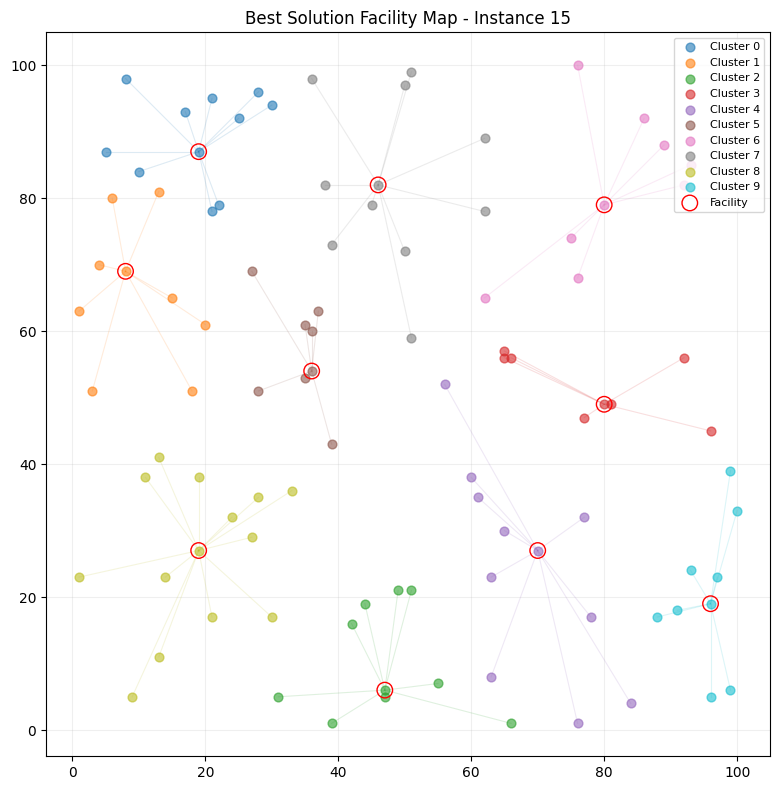

Capacity utilisation:
  Median 0: demand=106 / capacity=120  OK
  Median 1: demand=106 / capacity=120  OK
  Median 2: demand=120 / capacity=120  OK
  Median 3: demand=117 / capacity=120  OK
  Median 4: demand=116 / capacity=120  OK
  Median 5: demand=117 / capacity=120  OK
  Median 6: demand= 66 / capacity=120  OK
  Median 7: demand= 76 / capacity=120  OK
  Median 8: demand=115 / capacity=120  OK
  Median 9: demand=111 / capacity=120  OK


In [323]:
# Facility map - best solution (lowest service distance) from the Pareto front
best_idx = np.argmin(result["front_raw_dists"])
best_ind = result["front"][best_idx]
best_fac = compute_facility_locations(best_ind, inst.coords, inst.num_medians)

fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.colormaps.get_cmap("tab10").resampled(inst.num_medians)

for m in range(inst.num_medians):
    mask = best_ind == m
    ax.scatter(
        inst.coords[mask, 0], inst.coords[mask, 1],
        color=cmap(m), alpha=0.6, s=40, label=f"Cluster {m}"
    )
    # Draw lines from customers to their facility
    for ci in np.where(mask)[0]:
        ax.plot(
            [inst.coords[ci, 0], best_fac[m, 0]],
            [inst.coords[ci, 1], best_fac[m, 1]],
            color=cmap(m), alpha=0.15, linewidth=0.8
        )

# Facility locations as stars
ax.scatter(
    best_fac[:, 0], best_fac[:, 1],
    marker="o", s=125, color="red", facecolors='none', zorder=10, label="Facility"
)

ax.set_title(f"Best Solution Facility Map - Instance {inst.instance_id}")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.2)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# Print capacity utilisation
print("Capacity utilisation:")
for m in range(inst.num_medians):
    demand = inst.demands[best_ind == m].sum()
    print(f"  Median {m}: demand={demand:3d} / capacity={inst.capacity}  "
          f"{'VIOLATED' if demand > inst.capacity else 'OK'}")

# Results